### Setup

In [95]:
# Basic Util Packages
# from tqdm import tqdm
import logging
import time
import os

# Requests Packages
from concurrent.futures import ThreadPoolExecutor
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import requests
import json

# Image Processing Packages
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv


In [96]:
SF_API_URL = 'https://api.scryfall.com'
SF_API_HEADERS = {
    'User_Agent' : 'card-classifier/0.1',
    'Accept' : '*/*'
}
SF_API_DELAY = 50 # ms - No ratelimit on *.scryfall.io

In [97]:
DATA_UPDATE = False
ART_PATH = 'data\\art'

In [98]:
# Create a session
session = requests.Session()

# Configure the HTTPAdapter with a connection pool size
adapter = HTTPAdapter(
    pool_connections=10,  # Number of connection pools
    pool_maxsize=50,      # Maximum number of connections in the pool
    max_retries=Retry(total=3, backoff_factor=0.3)  # Retry strategy
)

# Mount the adapter to the session
session.mount('http://', adapter)
session.mount('https://', adapter)

Logging setup

In [99]:
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

### Helper Functions

In [100]:
def get_uris():
    ### Pull all download URIs
    response = session.get(SF_API_URL+'/bulk-data', headers=SF_API_HEADERS)
    data = response.json()['data']

    # Extract all URI
    download_uri = {}
    for object in data:
        download_uri[object['type']] = object['download_uri']
    return download_uri

def clean_cardname(name):
    return name.replace(' ', '_').replace('/', '_').replace(':', '_').replace('\'', '').replace('\"', '').replace('?', '').replace('!', '')


def download_image(entry, is_dfc=False, card_face=None):
    """
    Download a card image from a Scryfall JSON.

    Parameters:
    entry (dict): The card entry from Scryfall JSON.
    is_dfc (bool): Flag indicating if the card is a double-faced card.
    card_face (dict): The card face entry if the card is a double-faced card.

    Returns:
    None
    """
    if not is_dfc:
        filename = f"{clean_cardname(entry['name'])}_{entry['illustration_id']}.jpg"
        art_path = os.path.join(ART_PATH, filename)
        image_url = entry['image_uris']['art_crop']
    else:
        filename = f"{clean_cardname(card_face['name'])}_{card_face['illustration_id']}.jpg"
        art_path = os.path.join(ART_PATH, filename)
        image_url = card_face['image_uris']['art_crop']

    response = session.get(image_url, headers=SF_API_HEADERS)
    if response.status_code != 200:
        logging.error(f"Failed to download image for {entry['name']}: {response.status_code}")
        return
    with open(art_path, 'wb') as file:
        file.write(response.content)

def search_card_data(card_data, name=None, illustration_id=None, return_all=False):
    """
    Search for a downloaded card image by name or illustration ID.

    Parameters:
    - card_data (list): List of card data dictionaries.
    - name (str): Name of the card.
    - illustration_id (str): Illustration ID of the card.
    - return_all (bool): If True, return all matching cards in a List. If False, return only the first match as a Dict.

    Returns:
    - dict: Dictionary containing card data if one instance is found and return_all is False.
    - list: List of dictionaries containing card data if multiple instances are found and return_all is True.
    - None: If no matching card is found.
    """
    found_cards = []

    if name is None and illustration_id is None:
        logger.error("Both name and illustration_id cannot be None.")
        return None

    elif name is not None and illustration_id is not None:
        filename = f"{clean_cardname(name)}_{illustration_id}.jpg"
        art_path = os.path.join(ART_PATH, filename)
        if not os.path.exists(art_path):
            logger.error(f"File {art_path} does not exist.")
            return None

        art_dict = {'name': name,
                    'illustration_id': illustration_id,
                    'path': art_path}
        found_cards.append(art_dict)

    elif illustration_id is not None:
        for card in card_data:
            if card['illustration_id'] == illustration_id:
                filename = f"{clean_cardname(card['name'])}_{illustration_id}.jpg"
                art_path = os.path.join(ART_PATH, filename)
                if not os.path.exists(art_path):
                    logger.error(f"File {art_path} does not exist.")
                    return None

                art_dict = {'name': card['name'],
                            'illustration_id': illustration_id,
                            'path': art_path}
                found_cards.append(art_dict)

    elif name is not None:
        for card in card_data:
            if card['name'] == name:
                filename = f"{clean_cardname(card['name'])}_{card['illustration_id']}.jpg"
                art_path = os.path.join(ART_PATH, filename)
                if not os.path.exists(art_path):
                    logger.error(f"File {art_path} does not exist.")
                    return None

                art_dict = {'name': card['name'],
                            'illustration_id': card['illustration_id'],
                            'path': art_path}
                found_cards.append(art_dict)

    if len(found_cards) > 0:
        if return_all:
            return found_cards
        else:
            return found_cards[0]
    else:
        logger.error("No matching card found.")

    return None


def search_scryfall(query, unique = 'cards', include_extras = 'true', order='name'):
    """
    Function to search for cards using the Scryfall API

    Parameters:
    - query (str): The search query to use for the Scryfall API
    - unique (str): The uniqueness quality to use for the search (card, art, prints)
    - include_extras (str): Whether to include extra cards in the search (true, false)
    - order (str): The order to use for the search (name, set, released, rarity, etc.)

    Returns:
    - list: A list of card data dictionaries returned by the Scryfall API
    """
    # If result length is 175, likely another page
    data_len = 175
    search_data = []
    page = 1

    while data_len == 175:
        response = session.get(
            SF_API_URL + '/cards/search',
            headers=SF_API_HEADERS,
            params={
                'q': query,
                'unique': unique,
                'include_extras': include_extras,
                'order': order,
                'page': page
            }
        )
        search_data.extend(response.json()['data'])
        data_len = len(response.json()['data'])
        page += 1
    logger.info(f"Found {len(search_data)} cards for query: {query}")
    return search_data


def match_search_to_downloads(entry, is_dfc=False, card_face=None):
    """
    Match Scryfall search results to downloaded images.

    Parameters:
    - entry (dict): The card data dictionary from the Scryfall search.
    - is_dfc (bool): Whether the card is a double-faced card (DFC).
    - card_face (dict): The card face data dictionary if the card is a DFC.

    Returns:
    - dict: A dictionary containing the card name, illustration ID, and path to the image.
    """

    if not is_dfc:
        filename = f"{clean_cardname(entry['name'])}_{entry['illustration_id']}.jpg"
        art_path = os.path.join(ART_PATH, filename)
        art_dict = {'name': entry['name'],
                    'illustration_id': entry['illustration_id'],
                    'path': art_path}
    else:
        filename = f"{clean_cardname(card_face['name'])}_{card_face['illustration_id']}.jpg"
        art_path = os.path.join(ART_PATH, filename)
        art_dict = {'name': card_face['name'],
                    'illustration_id': card_face['illustration_id'],
                    'path': art_path}

    # Check if the file exists
    if not os.path.exists(art_path):
        logger.error(f"File {filename} does not exist.")
    return art_dict

### Download Card Images

#### Wipe Existing Images

In [101]:
import shutil
import os

data_folder = 'data'
art_folder = os.path.join(data_folder, 'art')
gitkeep_file = os.path.join(data_folder, '.gitkeep')
art_gitkeep_file = os.path.join(art_folder, '.gitkeep')

def clear_folder(folder, gitkeep_path):
    if os.path.exists(folder):
        for item in os.listdir(folder):
            item_path = os.path.join(folder, item)
            if item_path != gitkeep_path:
                if os.path.isfile(item_path) or os.path.islink(item_path):
                    os.unlink(item_path)
                elif os.path.isdir(item_path):
                    shutil.rmtree(item_path)
    else:
        os.makedirs(folder)
    # Ensure .gitkeep exists
    with open(gitkeep_path, 'w') as file:
        file.write('')

if DATA_UPDATE:
    clear_folder(data_folder, gitkeep_file)
    print(f"{data_folder} folder cleared")

    clear_folder(art_folder, art_gitkeep_file)
    print(f"{art_folder} folder cleared")

#### Download Bulk Data

In [102]:
artwork_file_path = os.path.join('data', 'unique_artwork.json')
# all_cards_file_path = os.path.join('data', 'all_cards.json')

if DATA_UPDATE:
    download_uri = get_uris()

    # Download and save the unique artwork file
    response = session.get(download_uri['unique_artwork'], headers=SF_API_HEADERS)
    with open(artwork_file_path, 'wb') as file:
        file.write(response.content)

    # Download and save the all cards
    # response = session.get(download_uri['all_cards'], headers=SF_API_HEADERS)
    # with open(all_cards_file_path, 'wb') as file:
    #     file.write(response.content)

#### Download Images

In [103]:
with open(artwork_file_path, 'r', encoding="utf8") as file:
    card_data = json.load(file)

# with open(all_cards_file_path, 'r', encoding="utf8") as file:
#     card_data = json.load(file)

if DATA_UPDATE:
    with ThreadPoolExecutor(max_workers=20) as executor:
        futures = []
        for entry in card_data:
            # If not DFC
            if 'image_uris' and 'illustration_id' in entry:
                future = executor.submit(download_image, entry)
                futures.append((future, entry))
            # If DFC
            elif 'card_faces' in entry:
                for card_face in entry['card_faces']:
                    future = executor.submit(download_image, entry, True, card_face)
                    futures.append((future, entry))
            # Likely no image, includes cards like dungeons
            else:
                logging.error(f"Unknown card type for {entry['name']}")
                continue

        print("Downloads Queued, waiting for completion...")
        for future, entry in futures:
            try:
                future.result()
            except Exception as e:
                logging.error(f"Error downloading image: {e}")


### Match Previously Tagged Cards to Downloaded Art

In [104]:
search_query = 'arttag:bisexual-lighting'
search_unique = 'art'
search_include_extras = 'true'

search_data = search_scryfall(search_query, search_unique, search_include_extras)

INFO:__main__:Found 315 cards for query: arttag:bisexual-lighting


In [105]:
with ThreadPoolExecutor() as executor:
    futures = []
    for search_card in search_data:
        # If not DFC
        if 'image_uris' in search_card:
            future = executor.submit(match_search_to_downloads, search_card)
            futures.append(future)
        # If DFC
        else:
            for card_face in search_card['card_faces']:
                future = executor.submit(match_search_to_downloads, search_card, True, card_face)
                futures.append(future)

# For art in futures.result, add to matches
search_matches = []
for future in futures:
    result = future.result()
    search_matches.append(result)

### Identify cards to be tagged

#### Helper Functions

In [141]:
def show_image(image=None, image_path=None, title=None):
    """
    Display an image using OpenCV.

    Parameters:
    - image (numpy.ndarray): The image to display.
    - image_path (str): The path to the image file.

    Returns:
    - None
    """
    if image is None and image_path is None:
        logger.error("Either image or image_path must be provided.")
        return
    if image_path is not None:
        image = cv.imread(image_path)
        image = cv.cvtColor(image, cv.COLOR_BGR2HSV)
        if image is None:
            logger.error(f"Image not found at {image_path}")
            return
    if title:
        plt.title(title)
    plt.imshow(cv.cvtColor(image, cv.COLOR_HSV2RGB))
    plt.axis('off')
    plt.show()
    
    
def identify_dominant_colors(image=None, image_path=None, K=5):
    """
    Identify the dominant colors in an image using K-Means clustering.
    Operates in HSV color space (converts BGR -> HSV if needed).

    Parameters:
    - image (numpy.ndarray): Image array (BGR or HSV).
    - image_path (str): The path to the image file.
    - K (int): The number of clusters (dominant colors) to identify.

    Returns:
    - list: A list of dominant colors in HSV format.
    - numpy.ndarray: The kmeans-quantized image in HSV.
    """
    # Read the image
    if image is None and image_path is None:
        logger.error("Either image or image_path must be provided.")
        return
    if image_path is not None:
        image = cv.imread(image_path)
        if image is None:
            logger.error(f"Image not found at {image_path}")
            return

    # Reshape the image to be a list of pixels
    Z = image.reshape((-1, 3)).astype(np.float32)

    # define criteria, number of clusters(K) and apply kmeans()
    criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, label, center = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

    # Now convert centers back into uint8, and make kmeans image
    center = np.uint8(center)
    res = center[label.flatten()]
    dominant_colors = center.tolist()

    # Reshape result to original image shape (HSV)
    kmean_img = res.reshape((image.shape))

    return dominant_colors, kmean_img

def is_blue(colour):
    """
    Determine if a given HSV color is classified as blue.

    Parameters:
    - colour (list or numpy.ndarray): The HSV color to check.

    Returns:
    - bool: True if the color is blue, False otherwise.
    """
    h, s, v = colour
    # Define blue color range in HSV
    return (h >= 80 and h <= 130) and (s >= 0) and (v >= 0)
    
def is_purple(colour):
    """
    Determine if a given HSV color is classified as purple.

    Parameters:
    - colour (list or numpy.ndarray): The HSV color to check.

    Returns:
    - bool: True if the color is purple, False otherwise.
    """
    h, s, v = colour
    # Define purple color range in HSV
    return (h >= 130 and h <= 160) and (s >= 0) and (v >= 0)

def is_red(colour):
    """
    Determine if a given HSV color is classified as red.

    Parameters:
    - colour (list or numpy.ndarray): The HSV color to check.

    Returns:
    - bool: True if the color is red, False otherwise.
    """
    h, s, v = colour
    # Define red color range in HSV
    return (h >= 0 and h <= 10) or (h >= 160 and h <= 180) and (s >= 0) and (v >= 0)

def display_color_swatches(colours):
    """
    Display color swatches for a list of HSV colors.

    Parameters:
    - colours (list): List of HSV colors.

    Returns:
    - None
    """
    cols = len(colours)
    swatch_h = 100
    indicator_h = 20
    swatch_w = 100

    swatch_hsv = np.zeros((swatch_h + indicator_h, swatch_w * cols, 3), dtype=np.uint8)
    
    for func in [is_blue, is_purple, is_red]:
        for i, c in enumerate(colours):
            x0 = i * swatch_w
            x1 = x0 + swatch_w
            swatch_hsv[0:swatch_h, x0:x1] = c  # broadcast fills (H,S,V)

            # Decide indicator: white (HSV 0,0,255) if blue else black (HSV 0,0,0)
            indicator_hsv = np.array([0, 0, 255], dtype=np.uint8) if func(c) else np.array([0, 0, 0], dtype=np.uint8)
            swatch_hsv[swatch_h:swatch_h+indicator_h, x0:x1] = indicator_hsv

        # Convert to RGB for display
        swatch_rgb = cv.cvtColor(swatch_hsv, cv.COLOR_HSV2RGB)

        plt.figure(figsize=(max(6, cols * 0.6), 3))
        plt.imshow(swatch_rgb)
        plt.axis('off')
        plt.title('Dominant colour swatches (white indicator = {})'.format(func.__name__))
        plt.show()
    
    

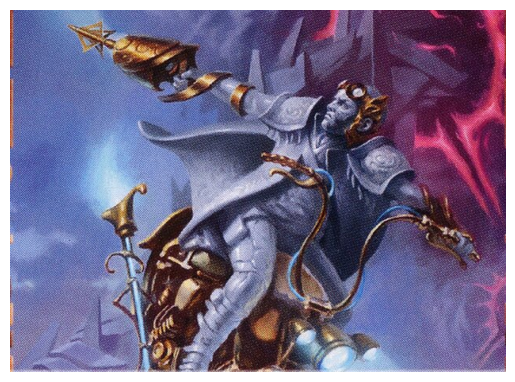

In [214]:
img = cv.imread(search_matches[269]['path'])
img = cv.cvtColor(img, cv.COLOR_BGR2HSV)


show_image(image=img)
colours, kmean_img = identify_dominant_colors(image=img, K=10)
# print(colours)
# show_image(image=kmean_img)


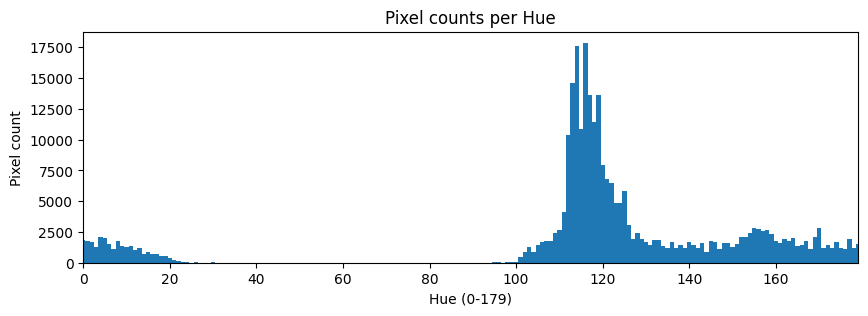

Total pixels: 286082
Top hues (hue, count):
116 17873
114 17591
113 14635
117 13659
119 13635
118 11404
115 10853
112 10386
120 7959
121 6786


In [215]:
# Count pixels for each hue (0-179) and plot the distribution
hsv_img = img.copy()

# Extract hue channel and compute counts
hues = hsv_img[:, :, 0].ravel()
counts = np.bincount(hues, minlength=180)

# Plot histogram of hue counts
plt.figure(figsize=(10, 3))
plt.bar(np.arange(180), counts, width=1.0)
plt.xlabel('Hue (0-179)')
plt.ylabel('Pixel count')
plt.title('Pixel counts per Hue')
plt.xlim(0, 179)
plt.show()

# Print summary and top hues
print(f"Total pixels: {counts.sum()}")
top_idxs = np.argsort(counts)[::-1][:10]
print("Top hues (hue, count):")
for h in top_idxs:
    print(h, int(counts[h]))


In [197]:
# result = search_card_data(card_data, name='Black Market Connections', return_all = True) #, illustration_id='54436824-977b-4dc7-8de1-8498e73e5ef2')

In [198]:
# # print(result['path'])
# for i in range(len(result)):
#     print(result[i]['path'])
#     plt.figure()
#     plt.title(f"{result[i]['name']}")
#     # plt.imshow(cv.cvtColor(cv.imread(result[i]['path']), cv.COLOR_BGR2RGB))
#     plt.imshow(cv.cvtColor(cv.imread(result[i]['path']), cv.COLOR_RGB2BGR))
# # plt.imshow(cv.cvtColor(cv.imread(result['path']), cv.COLOR_BGR2RGB))

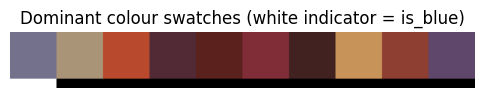

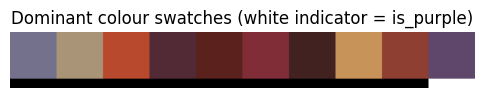

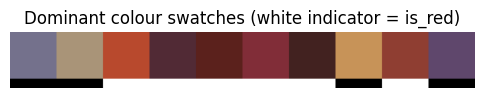

In [199]:
display_color_swatches(colours)

In [193]:
100/12.5

8.0